In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
exp_schema = {
    "Trametinib": {
        "target_genes": ['MAP2K1', 'MAP2K2'],
    },
    "Binimetinib": {
        "target_genes": ['MAP2K1', 'MAP2K2'],
    },
    "Dabrafenib": {
        "target_genes": ["BRAF", "BRAF_V600E", "RAF1"],
    },
    "Vemurafenib": {
        "target_genes": ["BRAF", "BRAF_V600E", "RAF1"],
    },
    "TAK-632": {
        "target_genes": ["BRAF", "RAF1"],
    },
    "Tucatinib": {
        "target_genes": ["ERBB2"],
    },
    "Regorafenib": {
        "target_genes": ["RAF1", "KIT", "PDGFRB", "RET", "FLT1", "KDR", "FLT4"],
    },
    "SOS1-IN-11": {
        "target_genes": ["SOS1"],
    },
    "SOS1-IN-15":{
        "target_genes": ["SOS1"],
    },
    "Palbociclib":{
        "target_genes": ["CDK4", "CDK6"],
    },
    "BAY-293": {
        "target_genes": ["SOS1"],
    },
    "BI-3406": {
        "target_genes": ["SOS1"],
    },
    'Alpelisib': {
        "target_genes" : ["PIK3CA", "PIK3CA_H1047R", "PIK3CA_E545K"],
    },
    'Erlotinib': {
        "target_genes" : ["EGFR", "EGFR_L858R", "EGFR_exon19del"],
    },
    'Olaparib': {
        "target_genes" : ["PARP1", "PARP2"],
    },
    'RMC6236': {
        "target_genes" : ["KRAS", "NRAS", "PPIA", "HRAS"],
    },
    'Sapanisertib': {
        "target_genes" : ["MTOR"],
    },
    'Selinexor': {
        "target_genes" : ["XPO1"],
    },
    'SN-38': {
        "target_genes" : ["TOP1"],
    },
    'Vociprotafib': {
        "target_genes" : ["PTPN11"],
    },
    'Navitoclax': {
        "target_genes" : ["BCL2", "BCL2L1", "BCL2L2"],
    },
    'Paclitaxel': {
        "target_genes" : ["TUBB"],
    },
}

In [7]:
ligands = list(exp_schema.keys())
ligands

['Trametinib',
 'Binimetinib',
 'Dabrafenib',
 'Vemurafenib',
 'TAK-632',
 'Tucatinib',
 'Regorafenib',
 'SOS1-IN-11',
 'SOS1-IN-15',
 'Palbociclib',
 'BAY-293',
 'BI-3406',
 'Alpelisib',
 'Erlotinib',
 'Olaparib',
 'RMC6236',
 'Sapanisertib',
 'Selinexor',
 'SN-38',
 'Vociprotafib',
 'Navitoclax',
 'Paclitaxel']

In [8]:
targets = []
for ligand in ligands:
    for t in exp_schema[ligand]['target_genes']:
        targets.append(t)
targets = list(set(targets))
targets

['XPO1',
 'EGFR_exon19del',
 'KDR',
 'PIK3CA_H1047R',
 'PIK3CA_E545K',
 'NRAS',
 'CDK6',
 'BCL2L2',
 'CDK4',
 'FLT1',
 'TOP1',
 'PDGFRB',
 'KIT',
 'SOS1',
 'BCL2',
 'PPIA',
 'HRAS',
 'MAP2K2',
 'BRAF_V600E',
 'TUBB',
 'PARP1',
 'RET',
 'PTPN11',
 'PARP2',
 'EGFR',
 'MTOR',
 'ERBB2',
 'EGFR_L858R',
 'BCL2L1',
 'MAP2K1',
 'RAF1',
 'BRAF',
 'PIK3CA',
 'FLT4',
 'KRAS']

In [5]:
len(targets)

35

In [ ]:
# path to proteome scan docking results
folder_path = ""
df_paths = pd.DataFrame(data=os.listdir(folder_path))

In [ ]:
n_ligand = []
top_n_targets = []
count_common_occurence = {}
count_known_targets_in_common_occurence = {}
total_targets = len(df_paths)
for n in range(1,total_targets+1):
    count_common_occurence[n] = []
    count_known_targets_in_common_occurence[n] = []
    for target_threshold in np.arange(0.05, 0.55, 0.05):
        df_list = []
        for filename in df_paths[0]:
            file_path = os.path.join(folder_path, filename)
            if filename.endswith('.csv'):
                temp_df = pd.read_csv(file_path)
                df_list.append(temp_df[:int(len(temp_df)*target_threshold)+1])

        f_df = pd.concat(df_list)['gene_name'].value_counts().reset_index()
        f_df.rename(columns={'count': 'occurrence in top'}, inplace=True)

        common_occurence = f_df[f_df['occurrence in top']>=n]['gene_name'].to_list()
        print(target_threshold)
        print(n)
        print(len(common_occurence))
        print("----")
        n_ligand.append(int(total_targets*n))
        top_n_targets.append(f"{int(100*target_threshold)}%")
        count_common_occurence[n].append(len(common_occurence))

        count_t = 0
        for t in targets:
            if t in common_occurence:
                count_t+=1
        count_known_targets_in_common_occurence[n].append(count_t)

In [ ]:
data = pd.DataFrame(count_common_occurence)
data_t = pd.DataFrame(count_known_targets_in_common_occurence)

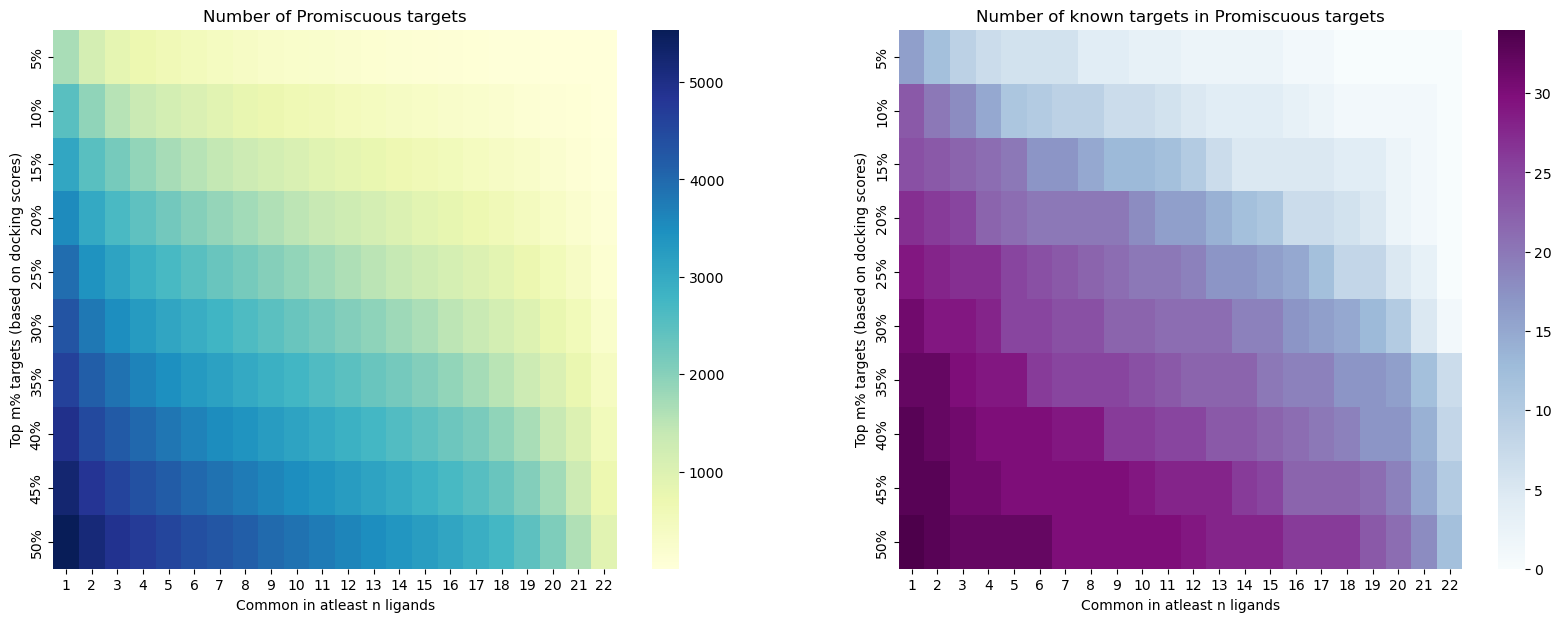

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
ax = sns.heatmap(data, cmap='YlGnBu', annot=False, yticklabels=['5%',
 '10%',
 '15%',
 '20%',
 '25%',
 '30%',
 '35%',
 '40%',
 '45%',
 '50%',], linewidths = 0, ax=axes[0])

ax.set_title("Number of Promiscuous targets")
ax.set_xlabel("Common in atleast n ligands")
ax.set_ylabel("Top m% targets (based on docking scores)")

ax = sns.heatmap(data_t, cmap='BuPu', annot=False, yticklabels=['5%',
 '10%',
 '15%',
 '20%',
 '25%',
 '30%',
 '35%',
 '40%',
 '45%',
 '50%',], linewidths = 0, ax=axes[1])

ax.set_title("Number of known targets in Promiscuous targets")
ax.set_xlabel("Common in atleast n ligands")
ax.set_ylabel("Top m% targets (based on docking scores)")

# Show the plot
plt.show()

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0, 0.5, '5%'),
  Text(0, 1.5, '10%'),
  Text(0, 2.5, '15%'),
  Text(0, 3.5, '20%'),
  Text(0, 4.5, '25%'),
  Text(0, 5.5, '30%'),
  Text(0, 6.5, '35%'),
  Text(0, 7.5, '40%'),
  Text(0, 8.5, '45%'),
  Text(0, 9.5, '50%')])

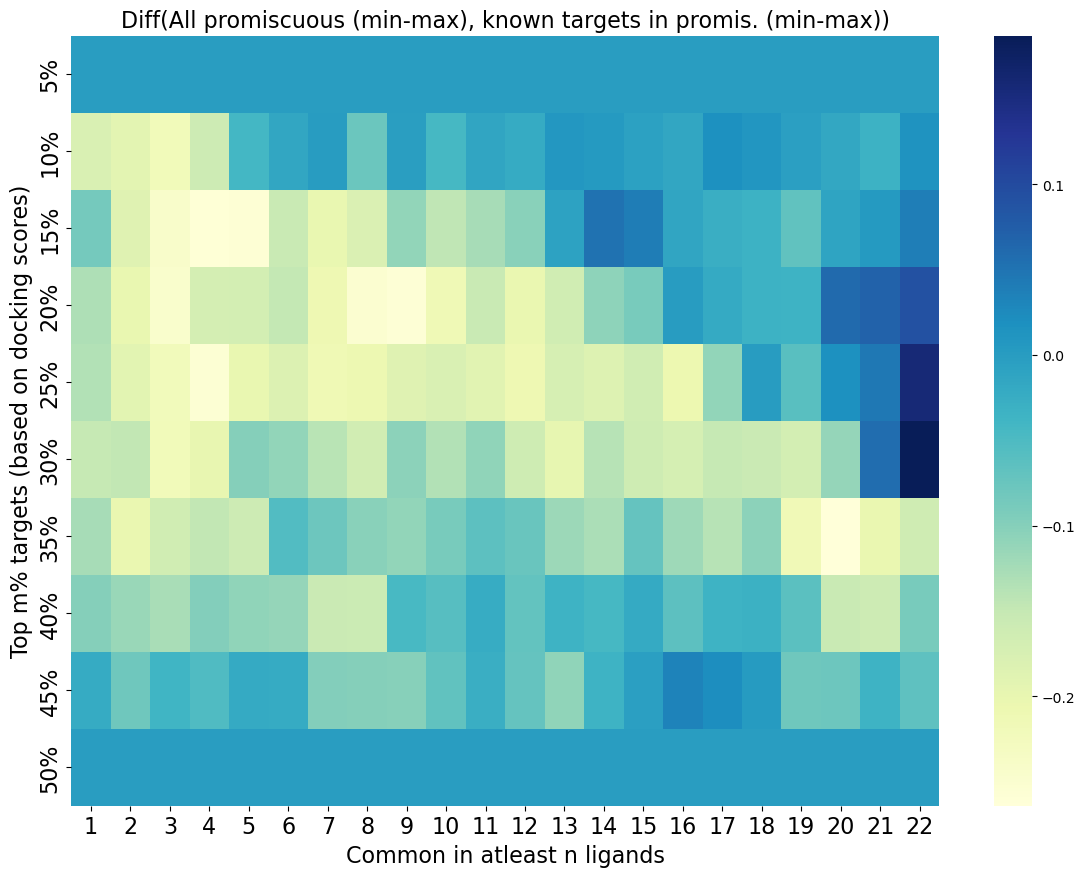

In [26]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler1 = MinMaxScaler()
scaler2 = MinMaxScaler()

data_normalized = pd.DataFrame(scaler1.fit_transform(data), columns=data.columns)
data_t_normalized = pd.DataFrame(scaler2.fit_transform(data_t), columns=data_t.columns)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(data_normalized-data_t_normalized, cmap='YlGnBu', annot=False, yticklabels=['5%',
 '10%',
 '15%',
 '20%',
 '25%',
 '30%',
 '35%',
 '40%',
 '45%',
 '50%',], linewidths = 0)

ax.set_title("Diff(All promiscuous (min-max), known targets in promis. (min-max))", fontsize=16)
ax.set_xlabel("Common in atleast n ligands", fontsize=16)
ax.set_ylabel("Top m% targets (based on docking scores)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

In [ ]:
## Scatter plot analysis

# import pandas as pd

# data.index.name = "Row2"

# # Melt the DataFrame
# result2 = data.reset_index().melt(id_vars="Row2", var_name="Column", value_name="Value_prom")

# # Combine the row and column into a single tuple-like column
# result2["Index"] = list(zip(result2["Row2"], result2["Column"]))

# # Drop the extra columns and reorder
# final_result2 = result2[["Index", "Value_prom"]]

# # Display the result
# print(final_result2)


# import pandas as pd

# data_t.index.name = "Row"

# # Melt the DataFrame
# result = data_t.reset_index().melt(id_vars="Row", var_name="Column", value_name="Value")

# # Combine the row and column into a single tuple-like column
# result["Index"] = list(zip(result["Row"], result["Column"]))

# # Drop the extra columns and reorder
# final_result = result[["Index", "Value"]]

# # Display the result
# print(final_result)


# df_oo = pd.DataFrame({'index': final_result['Index'], 'promis_count': final_result2['Value_prom'], 'target_count': final_result['Value']})
# df_oo['target_count'] = len(targets) - df_oo['target_count']

## Analyse individual thresholds -------------------------------------------------------
## df_oo.sort_values(by=["target_count", "promis_count"], ascending=False).query("promis_count>0")[:20].sort_values(by=["promis_count"], ascending=False)

## simple plot -------------------------------------------------------------------------
# ax = df_oo.plot.scatter(x="promis_count", y="target_count")
# ax.set_xlabel("Promiscuous count")
# ax.set_ylabel("Number of known targets not removed")

## for paper ---------------------------------------------------------------------------
# df_oo['tuple'] = df_oo.apply(lambda x: (x.promis_count, x.target_count), axis=1)
# df_oo[df_oo['tuple'].isin([(149, 35), (253, 34), (670,30), (1051,25)])].sort_values(by='promis_count')

# x=df_oo["promis_count"]
# y=df_oo["target_count"]


# highlight_indices = [214, 215, 132, 51]
# labels = {214: "A", 215: "B", 132: "C", 51: "D"}

# # Create High-Quality Scatter Plot
# fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# # Plot all points
# ax.scatter(x, y, s=20, c='blue', edgecolor='black', label="Data points")

# # Highlighted points
# ax.scatter(x[highlight_indices], y[highlight_indices], s=20, c='red', edgecolor='black', label="Highlighted points", zorder=3)

# # Add labels with leader lines
# for idx in highlight_indices:
#     ax.annotate(labels[idx],
#                 xy=(x[idx], y[idx]),               # Point to annotate
#                 xytext=(20, 3),                   # Offset label position (x, y) in points
#                 textcoords='offset points',
#                 ha='left',
#                 fontsize=9,
#                 color='red',
#                 arrowprops=dict(arrowstyle='-', color='black', lw=1))  # Arrow line

# # Axis Labels (Always include for clarity)
# ax.set_xlabel("Promiscuous Targets Count", fontsize=10)
# ax.set_ylabel("Number of Known Targets (Not Promiscuous)", fontsize=10)

# # Optional: Grid for readability
# ax.grid(True, linestyle='--', alpha=0.7)

# # No in-plot title for research paper figures
# # ax.set_title("Title")  # Omit this for paper submission

# # Tight layout and high-resolution save
# plt.tight_layout()
# plt.savefig("scatter_plot.png", dpi=300, bbox_inches='tight')

# plt.show()


analyse best promiscuity threshold 

In [28]:
target_threshold = 0.25
n = 22
df_list = []
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    
    # Check if the file is a CSV
    if filename.endswith('.csv'):
        # Read the CSV file into a DataFrame
        temp_df = pd.read_csv(file_path)
        df_list.append(temp_df[:int(len(temp_df)*target_threshold)+1])

f_df = pd.concat(df_list)['gene_name'].value_counts().reset_index()
f_df.rename(columns={'count': 'occurrence in top 50%'}, inplace=True)

Text(0, 0.5, 'Targets count')

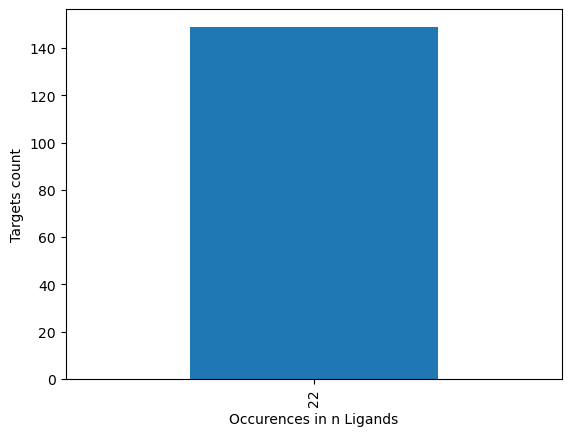

In [29]:
ax = f_df[f_df['occurrence in top 50%']>=n].value_counts('occurrence in top 50%').plot.bar()
ax.set_xlabel("Occurences in n Ligands")
ax.set_ylabel("Targets count")

In [30]:
common_occurence = f_df[f_df['occurrence in top 50%']>=n]['gene_name'].to_list()

In [31]:
len(common_occurence)

149

In [33]:
for gene in common_occurence:
    if gene in targets:
        print(gene)

Save Promiscuous Targets

In [ ]:
"""
index	 threshold  promis_count	target_count
(4, 22)	 25% - 22   149	            35
(5, 22)	 30% - 22   253	            34
(2, 14)	 15% - 14   670	            30
(1, 6)	 10% - 6    1051	        25
"""

'\nindex\t ACTUAL     promis_count\ttarget_count\n(4, 22)\t 25% -22    149\t            35\n(5, 22)\t 30% -22    253\t            34\n(2, 14)\t 15% -14    670\t            30\n(1, 6)\t 10% -6    1050\t            25\n'

In [ ]:
data_promis = {}

for target_threshold, n in [(25, 22), (30, 22), (15, 14), (10, 6)]:
    target_threshold/=100
    df_list = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        
        if filename.endswith('.csv'):
            temp_df = pd.read_csv(file_path)
            df_list.append(temp_df[:int(len(temp_df)*target_threshold)+1])

    f_df = pd.concat(df_list)['gene_name'].value_counts().reset_index()
    f_df.rename(columns={'count': 'occurrence in top 50%'}, inplace=True)
    common_occurence = f_df[f_df['occurrence in top 50%']>=n]['gene_name'].to_list()
    data_promis[(str(int(target_threshold*100)), str(n))] = common_occurence


In [ ]:
d2 ={}
for key, val in data_promis.items():
    print(key, len(val))
    for gene in val:
        if gene in targets:
            print(gene)
    d2["%_".join(key)] = val

In [ ]:
import json

with open("promiscuous_thresholds.json", "w") as f:
    json.dump(d2, f, indent=2)